# Laboratorio 4: Simulación del canal de counicaciones
**Curso:** Teoría de la Información Transmisión de Datos

En este laboratorio exploraremos cómo modelar y analizar canales de comunicación digitales con ruido, uno de los pilares de la Teoría de la Información de Shannon.

* **Canal Binario Simétrico (BSC):**

  $I(X;Y) \;=\; H_2\!\big( (1-f)p_1 + f(1-p_1) \big) \;-\; H_2(f)$

* **Canal con Borradura (BEC):**

  $I(X;Y) \;=\; (1 - f)\, H_2(p_1)$

* **Canal con Z:**

  $I(X;Y) \;=\; H_2\!\big( (1-f)p_1 \big) \;-\; p_1 \, H_2(f)$

Nota:

$f$: probabilidad de error del canal

$p_1 = P(X=1)$

## C1: Información mutua y capacidad del canal BSC

Este código implementa un análisis de la capacidad y la información mutua en un canal binario simétrico (BSC). Define la entropía binaria como medida de incertidumbre de una fuente binaria y, a partir de ella, calcula la información mutua entre la entrada y la salida del canal en función de la probabilidad de error de transmisión y de la distribución de la fuente. Con estos valores, se grafica la capacidad del canal y se ilustra cómo varía la información mutua para un caso particular $(f = 0.01)$, permitiendo visualizar de manera práctica los conceptos teóricos fundamentales de la teoría de la información.

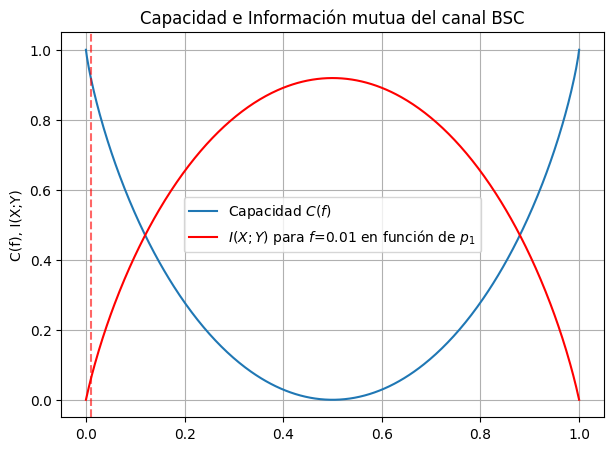

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Entropía binaria
def H2(p):
    p = np.clip(p, 1e-12, 1-1e-12)
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

# Información mutua para un BSC dado p (prob. error) y q = P(X=1)
def I_bsc(f, p1=0.5):
    py1 = (1-f)*p1 + f*(1-p1)  # probabilidad de que Y=1
    return H2(py1) - H2(f)

# Vector de probabilidades
p_vals = np.linspace(0, 1, 500)
C_vals = I_bsc(p_vals)

# Ejemplo con f = 0.01
f_test = 0.01
I_mutua = I_bsc(f_test, p_vals)

# Graficar
plt.figure(figsize=(7,5))
plt.plot(p_vals, C_vals, label="Capacidad $C(f)$")
plt.axvline(f_test, color="red", linestyle="--", alpha=0.6)
plt.plot(p_vals, I_mutua, color="red", label=f"$I(X;Y)$ para $f$={f_test} en función de $p_1$")


plt.title("Capacidad e Información mutua del canal BSC")
plt.ylabel("C(f), I(X;Y)")
plt.legend()
plt.grid(True)
plt.show()

## C2: Simulación del canal BSC

Este código realiza una simulación práctica de un canal binario simétrico (BSC) para contrastar los resultados teóricos con datos experimentales. Se genera una secuencia de bits equiprobables y se transmiten a través del canal, en el cual cada bit puede invertirse con una probabilidad de error $f$. La salida se obtiene aplicando una operación XOR entre la señal transmitida y el ruido. A partir de los datos generados, se calcula la información mutua empírica mediante la librería scikit-learn, así como la proporción de bits correctamente recibidos, y se comparan con la capacidad teórica del canal. De esta manera, el código permite observar en la práctica cómo la teoría de la información se refleja en simulaciones numéricas de transmisión digital.

In [2]:
from sklearn.metrics import mutual_info_score

def simulate_BSC(N=100000, f=0.001):
    # Fuente equiprobable
    X = np.random.randint(0, 2, N)
    # Canal BSC
    noise = np.random.rand(N) < f
    Y = np.bitwise_xor(X, noise.astype(int))
    return X, Y

# Ejemplo con f=0.01
f = 0.01
N = 100000
X, Y = simulate_BSC(N, f)

# Información mutua empírica (en bits)
I_empirica = mutual_info_score(X, Y) / np.log(2)

# Proporción de bits correctos
prop_correctos = 100*np.mean(X == Y)

print(f"Capacidad teórica (f={f}): {I_bsc(f):.3f} bits")
print(f"Información mutua empírica (f={f}): {I_empirica:.3f} bits")
print(f"Proporción de bits recibidos correctamente: {prop_correctos:.2f}%")


Capacidad teórica (f=0.01): 0.919 bits
Información mutua empírica (f=0.01): 0.921 bits
Proporción de bits recibidos correctamente: 99.02%


## Ejercicio 1: Canal con Borradura (BEC)

Repetir los procedimientos anteriores (C1 y C2) para el canal con borradura.

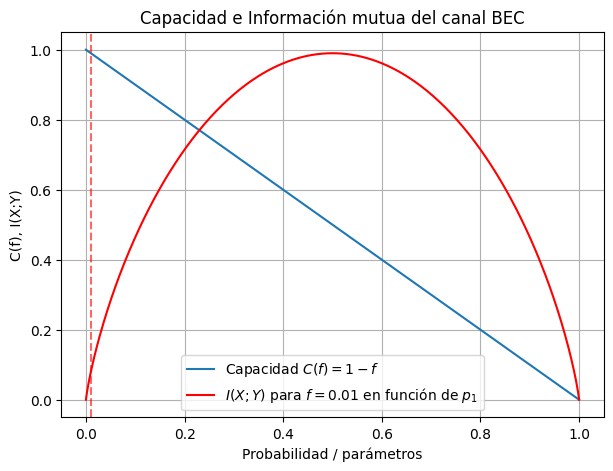

In [3]:
# Información mutua y capacidad del canal BEC (f=0.01)
import numpy as np
import matplotlib.pyplot as plt

# Entropía binaria
def H2(p):
    p = np.clip(p, 1e-12, 1-1e-12)
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

# Información mutua para un canal con borradura (BEC)
def I_bec(f, p1=0.5):
    return (1 - f) * H2(p1)

# Vector de probabilidades
p_vals = np.linspace(0, 1, 500)

# Capacidad del BEC: C(f) = 1 - f
f_vals = np.linspace(0, 1, 500)
C_vals = I_bec(p_vals)

# Ejemplo con f = 0.01 (probabilidad de borradura)
f_test = 0.01
I_mutua = I_bec(f_test, p_vals)

# Graficar
plt.figure(figsize=(7,5))
plt.plot(f_vals, C_vals, label="Capacidad $C(f) = 1 - f$")
plt.axvline(f_test, color="red", linestyle="--", alpha=0.6)
plt.plot(p_vals, I_mutua, color="red", label=f"$I(X;Y)$ para $f={f_test}$ en función de $p_1$")

plt.title("Capacidad e Información mutua del canal BEC")
plt.xlabel("Probabilidad / parámetros")
plt.ylabel("C(f), I(X;Y)")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
# Simulación del canal BEC (f=0.01)

import numpy as np
from sklearn.metrics import mutual_info_score

def simulate_BEC(N=100000, f=0.1):
    # Fuente equiprobable
    X = np.random.randint(0, 2, N)

    # Canal BEC: con probabilidad f, se borra el símbolo
    erasures = np.random.rand(N) < f
    Y = X.astype(object)  #  Cambio de Tipo de Dato porque necesitamos permitir símbolos no binarios
    Y[erasures] = -1      # usamos -1 para representar la borradura (E)

    return X, Y

# Parámetros de simulación
f = 0.01
N = 100000
X, Y = simulate_BEC(N, f)

# Filtramos solo las posiciones no borradas para calcular I(X;Y)
mask = (np.array(Y) != -1)
X_obs = np.array(X)[mask]
Y_obs = np.array(Y)[mask]

# Información mutua empírica (en bits)
I_empirica = mutual_info_score(X_obs, Y_obs) / np.log(2)

# Capacidad teórica (fuente equiprobable)
C_teorica = 1 - f

# Proporción de bits no borrados
prop_no_borrados = 100 * np.mean(mask)

print(f"Capacidad teórica (f={f}): {C_teorica:.3f} bits")
print(f"Información mutua empírica (f={f}): {I_empirica:.3f} bits")
print(f"Proporción de bits no borrados: {prop_no_borrados:.2f}%")


Capacidad teórica (f=0.01): 0.990 bits
Información mutua empírica (f=0.01): 1.000 bits
Proporción de bits no borrados: 98.95%


**Discuta aquí los resultados ofreciendo una explicación para los mismos**

...

## Ejercicio 2: Canal Z

Repetir los procedimientos anteriores (C1 y C2) para el canal Z.

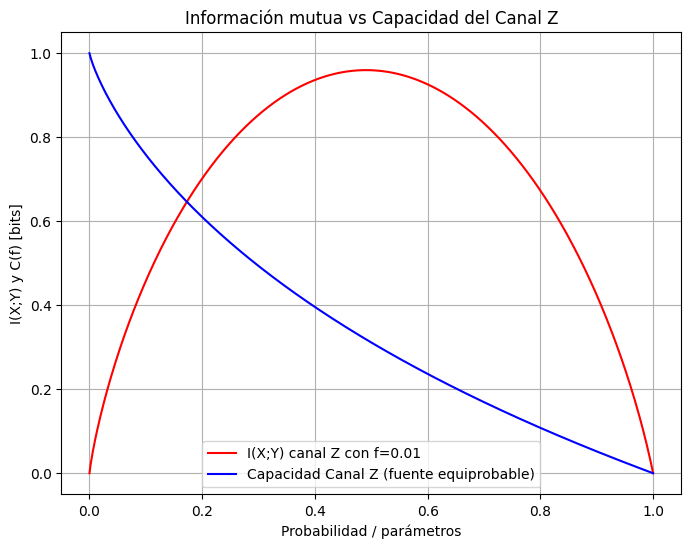

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Entropía binaria
def H2(p):
    p = np.clip(p, 1e-12, 1-1e-12)
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

# Información mutua del canal Z para un valor fijo de f
def I_z(f, p1):
    return H2(p1*(1-f)) - p1*H2(f)

# Capacidad del canal Z (fuente equiprobable)
def C_z(f):
    return H2(0.5*(1-f)) - 0.5*H2(f)

# Vector de probabilidades de entrada
p_vals = np.linspace(0, 1, 500)

# Frecuencia fija
f_test = 0.01
I_vals_fixed_f = I_z(f_test, p_vals)

# Capacidad como función de f
f_vals = np.linspace(0, 1, 500)
C_vals = C_z(f_vals)

# Graficar
plt.figure(figsize=(8,6))
plt.plot(p_vals, I_vals_fixed_f, color="red", label=f"I(X;Y) canal Z con f={f_test}")
plt.plot(f_vals, C_vals, color="blue", label="Capacidad Canal Z (fuente equiprobable)")

plt.title("Información mutua vs Capacidad del Canal Z")
plt.xlabel("Probabilidad / parámetros")
plt.ylabel("I(X;Y) y C(f) [bits]")
plt.legend()
plt.grid(True)
plt.show()




In [6]:
# Simulación del canal Z (f=0.01)

import numpy as np
from sklearn.metrics import mutual_info_score

def H2(p):
    """Entropía binaria en bits"""
    if p == 0 or p == 1:
        return 0
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

def I_Z(p1=0.5, f=0.1):
    """Información mutua teórica de un canal Z"""
    return H2((1-f)*p1) - p1*H2(f)

def simulate_Z_channel(N=100000, f=0.1):
    # Fuente equiprobable
    X = np.random.randint(0, 2, N)

    # Canal Z: 0 se transmite perfecto, 1 puede convertirse en 0
    Y = X.copy()
    errors = (X == 1) & (np.random.rand(N) < f)
    Y[errors] = 0

    return X, Y

# Parámetros de simulación
f = 0.6
N = 100000
X, Y = simulate_Z_channel(N, f)

# Información mutua empírica
I_empirica = mutual_info_score(X, Y) / np.log(2)

# Información mutua teórica (fuente equiprobable)
I_teorica = I_Z(0.5, f)

# Proporción de bits correctos
prop_correctos = 100*np.mean(X == Y)

print(f"Información mutua teórica (f={f}): {I_teorica:.3f} bits")
print(f"Información mutua empírica (f={f}): {I_empirica:.3f} bits")
print(f"Proporción de bits recibidos correctamente: {prop_correctos:.2f}%")


Información mutua teórica (f=0.6): 0.236 bits
Información mutua empírica (f=0.6): 0.235 bits
Proporción de bits recibidos correctamente: 69.92%


**Discuta aquí los resultados ofreciendo una explicación para los mismos**

### Discusión de los resultados

Las simulaciones confirman que las implementaciones de los modelos de canales de comunicación (Canal Binario Simétrico, Canal con Borradura y Canal en Z) estan alienadas con las fórmulas de información mutua derivadas de la teoría.

Para cada análisis se observa que la **información mutua teórica** calculada a partir de las fórmulas (`I_bsc`, `I_bec`, `I_Z`) es muy similar a la **información mutua empírica** obtenida al ausar la simulación.
La diferencia (pequeña) entre ambos valores se debe a la aleatoriedad aplicada para las simulaciones (y la cantidad finita de datos utilizados), lo cual es esperado.

Los resultados muestran que:
* Para cada tipo de canal, la información mutua disminuye a medida que aumenta la probabilidad de error del canal (`f`). Esto es lógico, ya que un mayor número de errores introduce más incertidumbre, lo que reduce la cantidad de información que el canal puede transmitir de manera confiable (un caso particular es el canal BSC con una parabola concava que se explica mas adelante).
* Para el **Canal Binario Simétrico (BSC)**, la información mutua es una función cóncava de la probabilidad de error. Cuando `f = 0.5`, el canal es completamente ruidoso (50% de probabilidad de error equivale a que no importa que dato se envíe desde la fuente, lo que se recibe en el receptor es completamente aleatorio), la información mutua se acerca a cero, lo que significa que el canal es inútil para la transmisión de datos.
* En el **Canal con Borradura (BEC)**, la información mutua depende directamente de la probabilidad de que un bit no sea borrado (`1-f`). Un valor `f=0.5` significa que se pierde la mitad de la información, lo que reduce la capacidad del canal.
* Para el **Canal en Z**, la información mutua también se reduce con el aumento de `f`, ya que la probabilidad de recibir un `1` de manera errónea se incrementa.

#Conclusión:

La cercania de los valores teóricos y los empíricos valida las implementaciones y las formulas teoricas aplicadas.
Queda ejemplificado como la **probabilidad de error** y la **entropía** afectan la cantidad de información que puede ser transmitida a través de un canal de comunicaciones ruidoso.